# Lab 7 — Image Segmentation and Feature Extraction
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook contains:
1. The two examples from the lab manual (Canny Edge Detection, Harris Corner Detection).
2. The assessment task (Otsu's thresholding).



## Setup — Import libraries

In [1]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from skimage import data   # provides sample images (camera, checkerboard, coins, ...)

# Make plots show inside the notebook
%matplotlib inline

## Task 1 — Canny Edge Detection

An **edge** is where brightness changes sharply. Canny finds edges in 5 steps: Gaussian blur → gradients → non-maximum suppression (thin the edges) → double thresholding → hysteresis (keep weak edges only if they connect to strong ones).

`cv2.Canny(img, T_low, T_high)`:
- `T_low` = lower threshold (weak edges)
- `T_high` = upper threshold (strong edges)
- Rule of thumb: `T_high ≈ 2×T_low` or `3×T_low`.

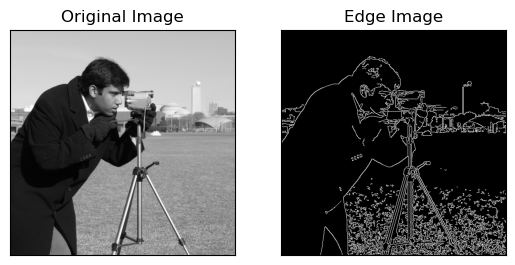

In [2]:
# --- Code from the lab manual ---
img = data.camera()

edges = cv2.Canny(img, 100, 200) #takes 3 parameters --> image and therhhold (lower , uppper ) less than lower --> black ( not an edge 0) , grater than upper (edge)
# in between 150 its depand on the pixel اللي مرتبط فيه لو كان كذا البيكسل عباره عن ايج بياخذ 255 لكن لو ماكان مرتبط بايج بياخذ 0
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

## Task 2 — Harris Corner Detection

A **corner** is a point where the image changes in *two* different directions, which makes corners highly distinctive.



- Large positive `R` → corner
- Large negative `R` → edge
- Small `R` → flat region

Parameters: `blockSize` (window size), `ksize` (Sobel kernel size), `k` (sensitivity, typically 0.04–0.06).

> **Note:** OpenCV uses BGR order, so `(0, 0, 255)` is red.

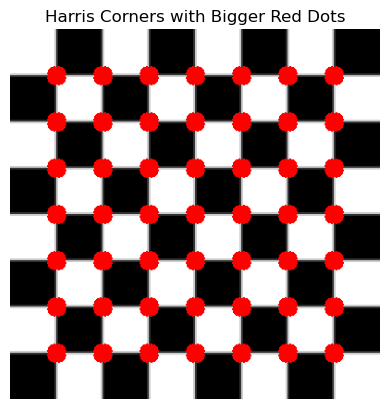

In [3]:
# --- Code from the lab manual ---
board = data.checkerboard()
image = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR) # optional 
image = cv2.resize(image, (400, 400), interpolation=cv2.INTER_NEAREST) #  optional also 

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)# convert image to gray because we want to do an mathmatocal operation 
gray = np.float32(gray) # conver from  int to float ( if u do not conert u will see an error )

# Harris Corner Detection
harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04) # blocksize = قد ايش راح يمشي كل مره
# ksize = kernal size 
# k = o.o4-0.06 constant valuse 
# i dont want all the keranl so do this step :
#  S1 :Threshold for detecting strong corners
threshold = 0.01 * harris.max() # the max num to the kornal (harris) *0.01 = i want only the stronger kornal which is 10% 
corner_coords = np.argwhere(harris > threshold)

# Draw larger red dots (radius = 7)
for y, x in corner_coords:
    # draw a circle
    cv2.circle(image, (x, y), radius=7, color=(0, 0, 255), thickness=-1)  # -1 = filled circle

# Display
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners with Bigger Red Dots')
plt.axis('off')
plt.show()

## Q1 — Otsu's Thresholding (Assessment Task)
Otsu picks `T` **automatically** by maximizing the between-class variance — assumes the histogram has two peaks (foreground + background).

show the original image, its histogram, and the thresholded image.

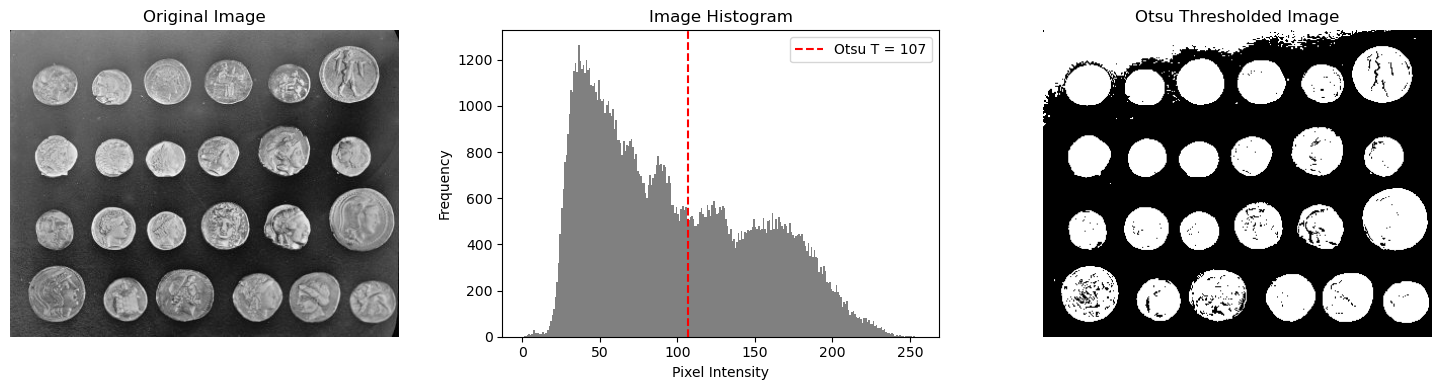

Optimal Otsu threshold: 107


In [4]:
# Q1 — Otsu's Thresholding
img = data.coins()  # Grayscale sample image

# Automatically calculate the optimal threshold using Otsu's method
otsu_threshold, binary_img = cv2.threshold(
    img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Display original image, histogram, and thresholded image
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].hist(img.ravel(), bins=256, range=(0, 256), color='gray')
axes[1].axvline(otsu_threshold, color='red', linestyle='--',
                label=f'Otsu T = {otsu_threshold:.0f}')
axes[1].set_title('Image Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].imshow(binary_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Otsu Thresholded Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f'Optimal Otsu threshold: {otsu_threshold:.0f}')


---
## Summary table

| Technique | Category | What it finds | OpenCV function |
|---|---|---|---|
| Canny | Edge detection | Thin connected edges | `cv2.Canny` |
| Sobel | Edge detection | Gradient magnitude (thick) | `cv2.Sobel` |
| Laplacian | Edge detection | Zero-crossings (2nd deriv) | `cv2.Laplacian` |
| Harris | Feature extraction | Corners | `cv2.cornerHarris` |
| Shi-Tomasi | Feature extraction | Corners (improved) | `cv2.goodFeaturesToTrack` |
| Simple threshold | Segmentation | Fixed-`T` binary mask | `cv2.threshold` |
| Otsu | Segmentation | Auto bimodal threshold | `cv2.threshold` + `THRESH_OTSU` |
| Adaptive threshold | Segmentation | Local-`T` binary mask | `cv2.adaptiveThreshold` |

**End of notebook.**